In [1]:
import os
import random
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import cv2
import shutil
from IPython.display import display, clear_output

# 数据目录
DATA_DIR = 'minet'

# 存储类别信息
class_info = {}
quality_issues = {}

# ========== 第1部分：遍历所有类别并统计信息 ==========
print("=== 数据探查与可视化 ===")
print()
print("1. 遍历所有类别并统计信息")
print("-" * 50)

# 不显示任何图像
for class_name in sorted(os.listdir(DATA_DIR)):
    class_path = os.path.join(DATA_DIR, class_name)
    if not os.path.isdir(class_path):
        continue
        # 统计样本数量
    images = [f for f in os.listdir(class_path) if f.endswith(('.jpg', '.jpeg', '.png', '.gif'))]
    num_samples = len(images)
    
    # 统计图片尺寸
    sizes = []
    issue_images = []
    
    for img_name in images:
        img_path = os.path.join(class_path, img_name)
        try:
            with Image.open(img_path) as img:
                sizes.append(img.size)
                
                # 检查图片质量
                img_array = np.array(img)
                
                # 转换为灰度图进行质量评估
                if len(img_array.shape) == 3:
                    gray = cv2.cvtColor(img_array, cv2.COLOR_RGB2GRAY)
                else:
                    gray = img_array
                
                # 检查模糊度 (使用拉普拉斯算子)
                laplacian = cv2.Laplacian(gray, cv2.CV_64F)
                blur_score = laplacian.var()
                
                # 检查过曝 (直方图分析)
                hist = cv2.calcHist([gray], [0], None, [256], [0, 256])
                overexposed = np.sum(hist[220:]) / hist.sum() > 0.3
                
                # 检查低对比度 (灰度范围)
                min_val, max_val = np.min(gray), np.max(gray)
                contrast = max_val - min_val
                low_contrast = contrast < 50
                
                if blur_score < 100 or overexposed or low_contrast:
                    issue = []
                    if blur_score < 100:
                        issue.append('blur')
                    if overexposed:
                        issue.append('overexposed')
                    if low_contrast:
                        issue.append('low_contrast')
                    issue_images.append((img_name, issue))
        except Exception as e:
            print(f"Error processing {img_path}: {e}")
    
    class_info[class_name] = {
        'num_samples': num_samples,
        'sizes': sizes
    }
    
    if issue_images:
        quality_issues[class_name] = issue_images
    
    # 打印当前类别的信息
    print(f"\n类别: {class_name}")
    print(f"样本数量: {num_samples}")
    if sizes:
        # 计算尺寸分布
        size_counts = {}
        for size in sizes:
            if size not in size_counts:
                size_counts[size] = 0
            size_counts[size] += 1
        
        print("图片尺寸分布:")
        for size, count in sorted(size_counts.items(), key=lambda x: x[1], reverse=True)[:5]:
            print(f"  {size}: {count}张")
        else:
            if len(size_counts) > 5:
                print(f"  ... 以及其他{len(size_counts)-5}种尺寸")

=== 数据探查与可视化 ===

1. 遍历所有类别并统计信息
--------------------------------------------------

类别: biotite
样本数量: 68
图片尺寸分布:
  (1300, 956): 4张
  (250, 250): 3张
  (300, 300): 2张
  (800, 600): 2张
  (1024, 768): 2张
  ... 以及其他54种尺寸

类别: bornite
样本数量: 171
图片尺寸分布:
  (800, 600): 15张
  (700, 525): 6张
  (1024, 768): 6张
  (450, 318): 5张
  (1300, 951): 5张
  ... 以及其他110种尺寸

类别: chrysocolla
样本数量: 162
图片尺寸分布:
  (1000, 1000): 7张
  (340, 270): 6张
  (300, 300): 6张
  (500, 500): 4张
  (177, 177): 3张
  ... 以及其他118种尺寸

类别: malachite
样本数量: 234
图片尺寸分布:
  (1000, 1000): 11张
  (800, 600): 9张
  (260, 208): 8张
  (300, 300): 6张
  (350, 350): 5张
  ... 以及其他158种尺寸

类别: muscovite
样本数量: 77
图片尺寸分布:
  (1000, 1000): 5张
  (1000, 700): 4张
  (1300, 956): 4张
  (737, 553): 3张
  (700, 700): 2张
  ... 以及其他57种尺寸

类别: pyrite
样本数量: 98
图片尺寸分布:
  (1000, 1000): 7张
  (1000, 700): 6张
  (1024, 1024): 5张
  (700, 800): 3张
  (480, 640): 2张
  ... 以及其他73种尺寸

类别: quartz
样本数量: 142
图片尺寸分布:
  (1000, 1000): 7张
  (650, 650): 6张
  (1920, 1080): 4张
  (1024, 1024

In [2]:
# ========== 第2部分：标注质量问题图片 ==========
print("\n" + "="*50)
print("2. 标注质量问题图片")
print("-" * 50)

if quality_issues:
    print("=== 质量问题图片 ===")
    for class_name, issues in quality_issues.items():
        print(f"\n类别: {class_name}")
        # 显示前20个问题图片
        show_count = min(20, len(issues))
        for img_name, issue_types in issues[:show_count]:
            print(f"  {img_name}: {', '.join(issue_types)}")
        if len(issues) > show_count:
            print(f"  ... 以及其他{len(issues)-show_count}张问题图片")
else:
    print("未发现质量问题图片")


2. 标注质量问题图片
--------------------------------------------------
=== 质量问题图片 ===

类别: biotite
  0001.jpg: overexposed
  0002.jpg: overexposed
  0007.jpg: overexposed
  0010.jpg: overexposed
  0012.jpg: overexposed
  0013.jpg: overexposed
  0018.jpg: overexposed
  0021.jpg: overexposed
  0023.jpg: overexposed
  0024.jpg: overexposed
  0026.jpg: overexposed
  0034.jpg: overexposed
  0035.jpg: overexposed
  0037.jpg: overexposed
  0039.jpg: overexposed
  0042.jpg: overexposed
  0044.jpg: overexposed
  0050.jpg: overexposed
  0051.jpg: overexposed
  0052.jpg: overexposed
  ... 以及其他7张问题图片

类别: bornite
  0002.jpg: overexposed
  0004.jpg: overexposed
  0005.jpg: overexposed
  0007.jpg: overexposed
  0009.jpg: overexposed
  0011.jpg: overexposed
  0012.jpg: overexposed
  0013.jpg: blur
  0016.jpg: overexposed
  0018.jpg: overexposed
  0019.jpg: overexposed
  0020.jpg: overexposed
  0021.jpg: overexposed
  0023.jpg: overexposed
  0027.jpg: overexposed
  0028.jpg: overexposed
  0031.jpg: overexpos

In [3]:
# ========== 第3部分：保存两个数据集副本（问题图片集和清洗后图片集）==========
print("\n" + "="*50)
print("3. 创建数据集副本")
print("-" * 50)

# 创建输出目录
output_dir = 'dataset_splits'
if os.path.exists(output_dir):
    shutil.rmtree(output_dir)  # 清空已存在的目录
os.makedirs(output_dir, exist_ok=True)

# 目录1：所有问题图片（不区分类别，统一存放）
problem_dir = os.path.join(output_dir, 'problem_images')
os.makedirs(problem_dir, exist_ok=True)

# 目录2：清洗后的正常图片（保持原始目录结构）
cleaned_dir = os.path.join(output_dir, 'cleaned_images')
os.makedirs(cleaned_dir, exist_ok=True)

# 统计信息
problem_count = 0
cleaned_count = 0

print("正在处理图片...")

for class_name, info in class_info.items():
    class_path = os.path.join(DATA_DIR, class_name)
    
    # 获取该类别的所有图片
    images = [f for f in os.listdir(class_path) if f.endswith(('.jpg', '.jpeg', '.png', '.gif'))]
    
    # 获取该类别的质量问题图片（如果有）
    if class_name in quality_issues:
        problem_images = set([img_name for img_name, _ in quality_issues[class_name]])
    else:
        problem_images = set()
    
    # 保存清洗后的图片（保持类别结构）
    class_cleaned_dir = os.path.join(cleaned_dir, class_name)
    os.makedirs(class_cleaned_dir, exist_ok=True)
    
    for img_name in images:
        src_path = os.path.join(class_path, img_name)
        
        if img_name in problem_images:
            # 问题图片：统一保存到problem_images目录
            # 重命名以保留类别信息：类别_原文件名
            new_name = f"{class_name}_{img_name}"
            dst_path = os.path.join(problem_dir, new_name)
            shutil.copy2(src_path, dst_path)
            problem_count += 1
        else:
            # 正常图片：保持类别结构保存到cleaned_images
            dst_path = os.path.join(class_cleaned_dir, img_name)
            shutil.copy2(src_path, dst_path)
            cleaned_count += 1

print(f"\n✅ 数据副本创建完成！")
print(f"   问题图片总数: {problem_count} 张")
print(f"   正常图片总数: {cleaned_count} 张")
print(f"\n保存位置:")
print(f"   - 问题图片集: {problem_dir}")
print(f"   - 清洗后数据集: {cleaned_dir}")

# 生成统计报告
report_path = os.path.join(output_dir, 'dataset_split_report.txt')
with open(report_path, 'w', encoding='utf-8') as f:
    f.write("=== 数据集分割报告 ===\n\n")
    f.write(f"问题图片总数: {problem_count}\n")
    f.write(f"正常图片总数: {cleaned_count}\n")
    f.write(f"总图片数: {problem_count + cleaned_count}\n\n")
    f.write("各类别统计:\n")
    for class_name, info in class_info.items():
        images = [f for f in os.listdir(os.path.join(DATA_DIR, class_name)) 
                 if f.endswith(('.jpg', '.jpeg', '.png', '.gif'))]
        total = len(images)
        if class_name in quality_issues:
            problem = len(quality_issues[class_name])
        else:
            problem = 0
        clean = total - problem
        f.write(f"{class_name}: 总计{total}张 (问题:{problem}, 正常:{clean})\n")
    
    # 写入质量问题类型统计
    f.write("\n=== 质量问题类型统计 ===\n")
    issue_type_count = {'blur': 0, 'overexposed': 0, 'low_contrast': 0}
    for class_name, issues in quality_issues.items():
        for _, issue_types in issues:
            for issue_type in issue_types:
                issue_type_count[issue_type] += 1
    for issue_type, count in issue_type_count.items():
        f.write(f"{issue_type}: {count}次\n")

print(f"   统计报告: {report_path}")


3. 创建数据集副本
--------------------------------------------------
正在处理图片...

✅ 数据副本创建完成！
   问题图片总数: 371 张
   正常图片总数: 581 张

保存位置:
   - 问题图片集: dataset_splits\problem_images
   - 清洗后数据集: dataset_splits\cleaned_images
   统计报告: dataset_splits\dataset_split_report.txt



5. 数据分布总结
--------------------------------------------------
=== 类别分布 ===
biotite: 68张 (问题:27, 正常:41)
bornite: 171张 (问题:71, 正常:100)
chrysocolla: 162张 (问题:70, 正常:92)
malachite: 234张 (问题:90, 正常:144)
muscovite: 77张 (问题:21, 正常:56)
pyrite: 98张 (问题:32, 正常:66)
quartz: 142张 (问题:60, 正常:82)

总样本数: 952张
类别数量: 7个


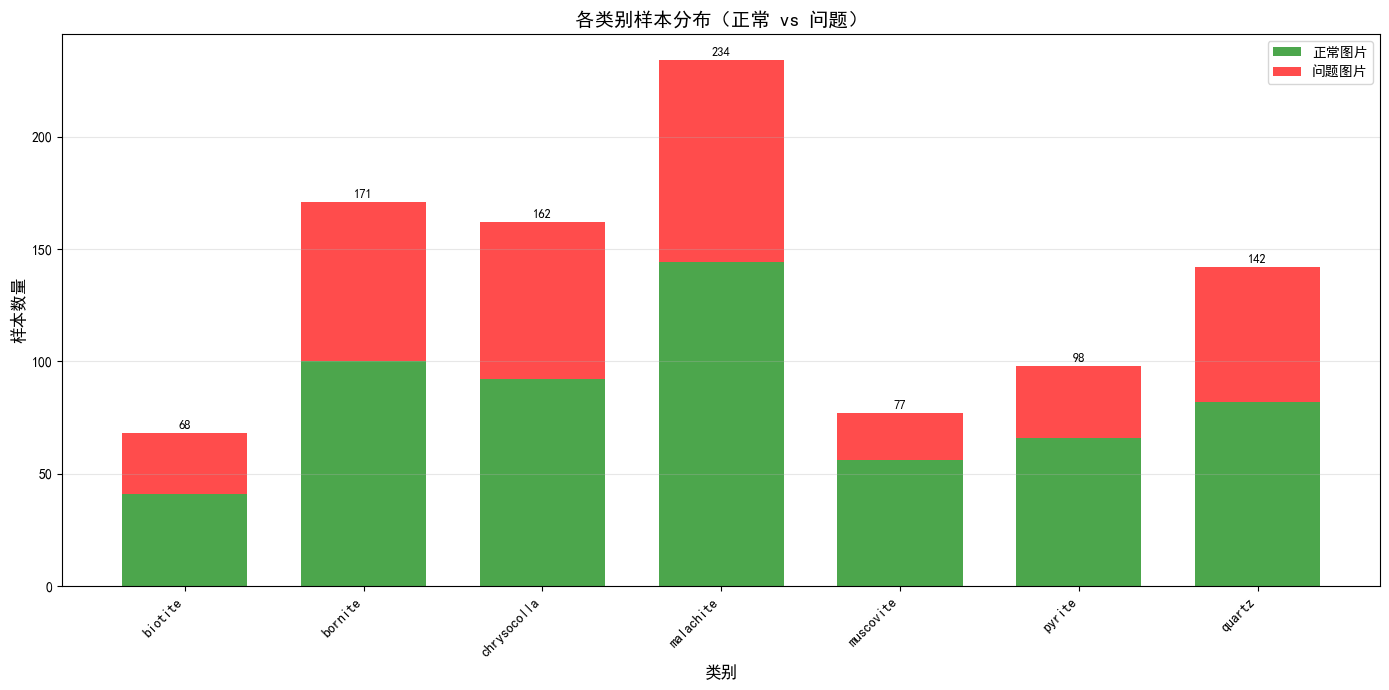


=== 质量问题类型统计 ===
各类型问题数量:
  blur: 101张
  overexposed: 317张
  low_contrast: 0张


C:\Users\1\AppData\Local\Temp\ipykernel_28840\935784142.py:96: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax2.set_xticklabels(categories, rotation=45, ha='right')


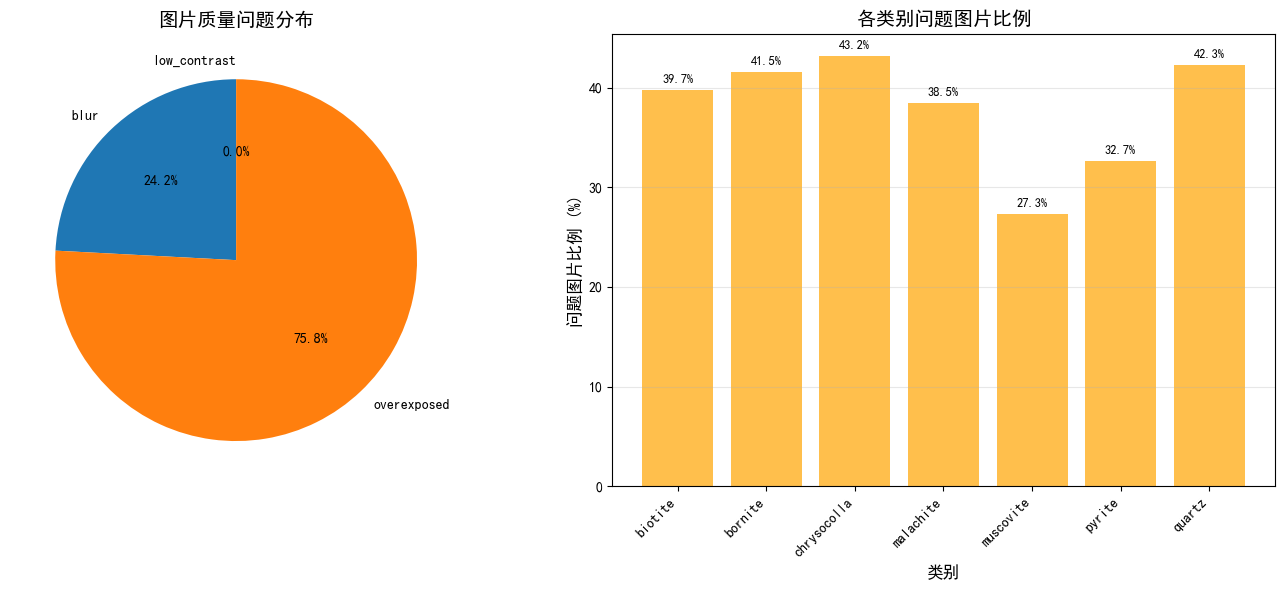


数据探查与可视化完成！

📁 生成的文件:
   - 问题图片集: dataset_splits\problem_images
   - 清洗后数据集: dataset_splits\cleaned_images
   - 统计报告: dataset_splits\dataset_split_report.txt


In [5]:
# ========== 第5部分：数据分布总结及可视化 ==========
plt.rcParams['font.sans-serif'] = ['SimHei', 'DejaVu Sans', 'Arial Unicode MS', 'WenQuanYi Zen Hei']
plt.rcParams['axes.unicode_minus'] = False  # 解决负号显示问题
print("\n" + "="*50)
print("5. 数据分布总结")
print("-" * 50)

print("=== 类别分布 ===")
total_samples = 0
class_names = []
sample_counts = []
problem_counts = []
clean_counts = []

for class_name, info in sorted(class_info.items()):
    total_samples += info['num_samples']
    class_names.append(class_name)
    sample_counts.append(info['num_samples'])
    
    if class_name in quality_issues:
        problem = len(quality_issues[class_name])
    else:
        problem = 0
    clean = info['num_samples'] - problem
    
    problem_counts.append(problem)
    clean_counts.append(clean)
    
    print(f"{class_name}: {info['num_samples']}张 (问题:{problem}, 正常:{clean})")

print(f"\n总样本数: {total_samples}张")
print(f"类别数量: {len(class_info)}个")

# 绘制类别分布堆叠条形图（正常 vs 问题）
fig, ax = plt.subplots(figsize=(14, 7))

x = np.arange(len(class_names))
width = 0.7

# 堆叠条形图
ax.bar(x, clean_counts, width, label='正常图片', color='green', alpha=0.7)
ax.bar(x, problem_counts, width, bottom=clean_counts, label='问题图片', color='red', alpha=0.7)

ax.set_xlabel('类别', fontsize=12)
ax.set_ylabel('样本数量', fontsize=12)
ax.set_title('各类别样本分布（正常 vs 问题）', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(class_names, rotation=45, ha='right')
ax.legend()
ax.grid(axis='y', alpha=0.3)

# 添加数值标签
for i, (clean, problem) in enumerate(zip(clean_counts, problem_counts)):
    total = clean + problem
    if total > 0:
        ax.text(i, total + 1, str(total), ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

# 如果有质量问题，显示问题统计
if quality_issues:
    print("\n=== 质量问题类型统计 ===")
    issue_types_count = {'blur': 0, 'overexposed': 0, 'low_contrast': 0}
    for class_name, issues in quality_issues.items():
        for _, issue_types in issues:
            for issue_type in issue_types:
                issue_types_count[issue_type] += 1
    
    print("各类型问题数量:")
    for issue_type, count in issue_types_count.items():
        print(f"  {issue_type}: {count}张")
    
    # 绘制问题类型饼图
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
    
    # 问题类型饼图
    issue_labels = list(issue_types_count.keys())
    issue_values = list(issue_types_count.values())
    ax1.pie(issue_values, labels=issue_labels, autopct='%1.1f%%', startangle=90)
    ax1.set_title('图片质量问题分布', fontsize=14)
    
    # 各类别问题比例图
    categories = []
    problem_ratios = []
    for class_name in class_names:
        total = sample_counts[class_names.index(class_name)]
        problem = problem_counts[class_names.index(class_name)]
        problem_ratios.append(problem / total * 100 if total > 0 else 0)
        categories.append(class_name)
    
    bars = ax2.bar(categories, problem_ratios, color='orange', alpha=0.7)
    ax2.set_xlabel('类别', fontsize=12)
    ax2.set_ylabel('问题图片比例 (%)', fontsize=12)
    ax2.set_title('各类别问题图片比例', fontsize=14)
    ax2.set_xticklabels(categories, rotation=45, ha='right')
    ax2.grid(axis='y', alpha=0.3)
    
    # 添加数值标签
    for bar, ratio in zip(bars, problem_ratios):
        ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, 
                f'{ratio:.1f}%', ha='center', va='bottom', fontsize=9)
    
    plt.tight_layout()
    plt.show()

print("\n" + "="*50)
print("数据探查与可视化完成！")
print("\n📁 生成的文件:")
print(f"   - 问题图片集: {problem_dir}")
print(f"   - 清洗后数据集: {cleaned_dir}")
print(f"   - 统计报告: {report_path}")